# Impact functions

In this notebook we read Entity files for Porto Alegre, Brazil and plot (uncalibrated) Impact Functions for housing, businesses and schools.

## Impact functions from the Entity file

Impact functions describe the relationship between the intensity of a hazard and its effect on your chosen exposure.

They are stored in the Entity Excel workbook in the 'impact_functions' sheet. The sheet can specify any number of impact functions. Each function is read in and stored in an `ImpactFunc` object, which are then grouped into an `ImpactFuncSet` object and stored in the `Entity`'s `impact_funcs` attribute.

All of these classes are part of CLIMADA's `climada.entity` package.

There are two ways to create impact functions for an analysis: from an Entity file, or programatically by constructing an `ImpactFunc` object. This notebook reads from a file. For more information on Impact Functions, see the [CLIMADA User Guide](https://climada-python.readthedocs.io/en/stable/user-guide/climada_entity_ImpactFuncSet.html).

Let's read in the Entity files and visualize the functions:

In [1]:
from pathlib import Path

# Set the directory where our Entity files are located
ENTITY_DIR = "../data/entity_files_uncalibrated/"
# Give a list of Entity file names (so we can examine more than one file if we want)
ENTITY_FILES = ["Porto_Alegre_BRAZIL_Entity_Floods_Residential.xlsx", "Porto_Alegre_BRAZIL_Entity_Floods_Companies.xlsx", "Porto_Alegre_BRAZIL_Entity_Floods_Schools.xlsx"]

entity_filepaths = [Path(ENTITY_DIR) / filename for filename in ENTITY_FILES]

In [2]:
from climada.entity import Entity

# Read in the files
entity_list = []
for filepath in entity_filepaths:
    print(f"Reading {filepath.name}...")
    entity = Entity.from_excel(filepath)
    entity.exposures.ref_year = 2026    # Set reference year
    entity.exposures.value_unit = "USD"
    entity.exposures.description = f"Exposures from {filepath.name}"
    entity_list.append(entity)

Reading Porto_Alegre_BRAZIL_Entity_Floods_Residential.xlsx...
Reading Porto_Alegre_BRAZIL_Entity_Floods_Companies.xlsx...
Reading Porto_Alegre_BRAZIL_Entity_Floods_Schools.xlsx...


In [3]:
HAZ_TYPE = "FL"  # This is the code we use to indicate impact functions for floods in Impact Functions

# We can then store the impact function sets in their own list:
impf_set_list = [entity.impact_funcs for entity in entity_list]

for filename, impf_set in zip(ENTITY_FILES, impf_set_list):
    print(f"There are {impf_set.size()} impact functions in {filename} with IDs {impf_set.get_ids(haz_type=HAZ_TYPE)}.")

There are 2 impact functions in Porto_Alegre_BRAZIL_Entity_Floods_Residential.xlsx with IDs [101, 102].
There are 2 impact functions in Porto_Alegre_BRAZIL_Entity_Floods_Companies.xlsx with IDs [201, 202].
There are 2 impact functions in Porto_Alegre_BRAZIL_Entity_Floods_Schools.xlsx with IDs [301, 302].


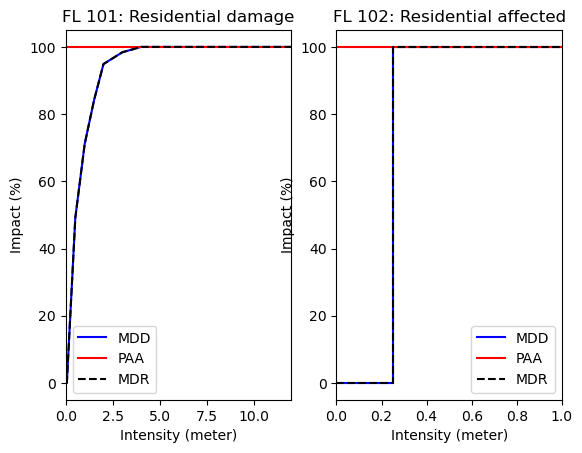

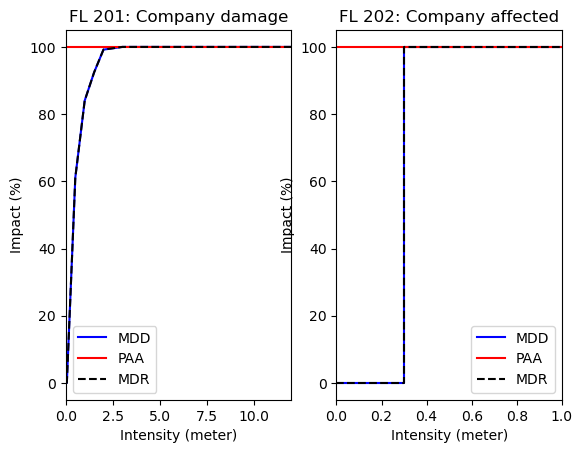

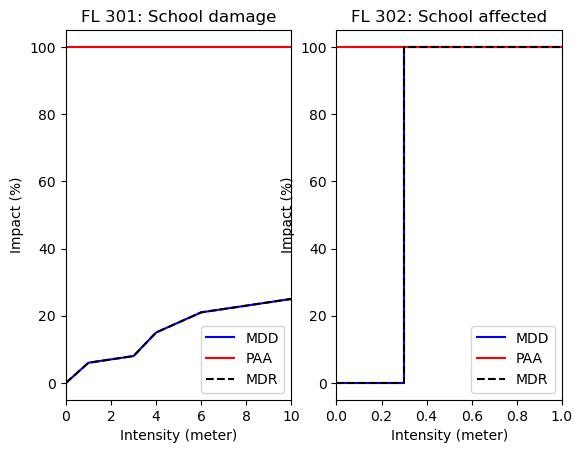

In [4]:
# Visualize the impact functions
# (this can be quite messy when you have multiple functions)
for impf_set in impf_set_list:
    impf_set.plot(fun_id=None)  # Specify fun_id to plot a single function

An impact function is defined by the following properties:

In [5]:
# Choose an example impact function to examine in more detail
example_impf_set = impf_set_list[0]
example_fun_ids = example_impf_set.get_ids(haz_type=HAZ_TYPE)
example_impf = example_impf_set.get_func(haz_type=HAZ_TYPE,fun_id=example_fun_ids[0])

print(f"Details from an example impact function:")
# The function ID
print(f"Function ID: {example_impf.id}")
# The hazard type ('None' is acceptable)
print(f"Hazard type: {example_impf.haz_type}")
# The intensity unit
print(f"Intensity unit: {example_impf.intensity_unit}")
# The intensity values for which damage is defined
print(f"Intensity values: {example_impf.intensity}")
# The mean damage degree values: the average damage experienced by assets at these hazard intensities
print(f"Mean damage degree values: {example_impf.mdd}")
# The percentage of assets affected: the average percentage of assets affected by this intensity of hazard at a single location
print(f"Percentage of assets affected: {example_impf.paa}")
# The name (optionally)
print(f"Name: {example_impf.name}")

Details from an example impact function:
Function ID: 101
Hazard type: FL
Intensity unit: meter
Intensity values: [ 0.    0.05  0.5   1.    1.5   2.    3.    4.    5.    6.   12.  ]
Mean damage degree values: [0.    0.    0.491 0.711 0.842 0.949 0.984 1.    1.    1.    1.   ]
Percentage of assets affected: [1 1 1 1 1 1 1 1 1 1 1]
Name: Residential damage
